In [21]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import re
import sys
from pathlib import Path
import logging
from glob import glob

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [33]:
# Configuration
config = {
    'input_data_bow': project_root / 'data' / 'input_data' / 'for_report' / 'bow',
    'input_data_oldman': project_root / 'data' / 'input_data' / 'for_report' / 'oldman',
    'gap_filled_bow_canswe_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' /'bow_swe_gapfilled_data_final.nc',
    'gap_filled_oldman_canswe_data' : project_root / 'data' / 'output_data' / 'for_report'/'oldman' /'oldman_swe_gapfilled_data_final.nc',
    'canswe_bow_original_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' / 'bow_canswe_selected_final.nc',
    'canswe_oldman_original_data' : project_root / 'data' / 'output_data' / 'for_report'/'oldman' / 'oldmancanswe_selected_final.nc',
    'shapefile': project_root / 'data' / 'input_data' / 'shapefiles'/'BowRiverBasin'/'Bow_elevation_combined.shp',
    'output_plots': project_root / 'data' / 'output_data' / 'for_report'}

# Data preparation
Functions

In [3]:
def extract_station_id(filepath):
    """
    Extract station id from filenames like:
    porExtract_AB_05BB803_PC_CmdTotal.Merged.C.csv
    """
    fname = Path(filepath).name
    m = re.search(r'AB_([A-Z0-9]+)_', fname)
    return m.group(1) if m else fname

def read_alberta_timeseries(filepath, value_name):
    """
    Read Alberta web-export CSV with 22-line header.
    Returns columns: time, station_id, <value_name>
    """
    station_id = extract_station_id(filepath)

    df = pd.read_csv(filepath, skiprows=22)
    df.columns = [c.strip() for c in df.columns]

    # combine Date and Time
    df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
    df = df.dropna(subset=['time']).copy()

    # value column
    value_col = [c for c in df.columns if 'Value' in c][0]

    df = df[['time', value_col]].rename(columns={value_col: value_name})
    df['station_id'] = station_id

    return df[['time', 'station_id', value_name]]

def daily_aggregate(df, value_col, how='sum'):
    """
    Aggregate to daily data by station.
    """
    if how == 'sum':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .sum()
              .reset_index()
        )
    elif how == 'mean':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .mean()
              .reset_index()
        )
    elif how == 'last':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .last()
              .reset_index()
        )
    else:
        raise ValueError("how must be 'sum', 'mean', or 'last'")

    return out

def add_seasonal_year_oct_may(df, time_col='time'):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    out['month'] = out[time_col].dt.month
    out['year'] = out[time_col].dt.year

    out = out[out['month'].isin([10, 11, 12, 1, 2, 3, 4, 5])].copy()

    out['Seasonal_Year'] = out['year']
    out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'Seasonal_Year'] = (
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
    )

    return out

def combine_daily_swe_precip(folder, swe_pattern='*SW*.csv', precip_pattern='*PC*.csv',
                             swe_agg='last', precip_agg='sum', add_season_year=True):
    folder = Path(folder)

    swe_files = sorted(glob(str(folder / swe_pattern)))
    precip_files = sorted(glob(str(folder / precip_pattern)))

    if not swe_files:
        raise FileNotFoundError(f"No SWE files found with pattern: {swe_pattern}")
    if not precip_files:
        raise FileNotFoundError(f"No precip files found with pattern: {precip_pattern}")

    swe_all = pd.concat(
        [read_alberta_timeseries(f, 'SWE') for f in swe_files],
        ignore_index=True
    )
    precip_all = pd.concat(
        [read_alberta_timeseries(f, 'Precipitation') for f in precip_files],
        ignore_index=True
    )

    swe_daily = daily_aggregate(swe_all, 'SWE', how=swe_agg)
    precip_daily = daily_aggregate(precip_all, 'Precipitation', how=precip_agg)

    combined = pd.merge(
        swe_daily,
        precip_daily,
        on=['time', 'station_id'],
        how='outer'
    ).sort_values(['station_id', 'time']).reset_index(drop=True)

    if add_season_year:
        combined = add_seasonal_year_oct_may(combined, time_col='time')

    return combined

In [4]:
folder = config['input_data']

combined_daily_df = combine_daily_swe_precip(
    folder=folder,
    swe_agg='last',
    precip_agg='sum',
    add_season_year=True
)

display(combined_daily_df.head())
print(combined_daily_df.columns)

KeyError: 'input_data'

In [5]:
# save combined_daily_df to output folder for later use
output_path = config['output_plots'] / 'combined_daily_swe_precip.csv'
combined_daily_df.to_csv(output_path, index=False)

In [5]:
# extract data for season year 2025
season_2025_df = combined_daily_df[combined_daily_df['Seasonal_Year'] == 2025].copy()

# add prefix 'ALE-' and 'P' to station_id
season_2025_df['station_id'] = 'ALE-' + season_2025_df['station_id'] + 'P'
display(season_2025_df)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year
205,ALE-05BB803P,2025-10-01,1.0,2.8,10,2025,2025
206,ALE-05BB803P,2025-10-02,4.0,0.6,10,2025,2025
207,ALE-05BB803P,2025-10-03,1.0,0.0,10,2025,2025
208,ALE-05BB803P,2025-10-04,4.0,3.0,10,2025,2025
209,ALE-05BB803P,2025-10-05,8.0,0.0,10,2025,2025
...,...,...,...,...,...,...,...
2190,ALE-05CA805P,2026-03-07,405.0,4.8,3,2026,2025
2191,ALE-05CA805P,2026-03-08,419.0,16.6,3,2026,2025
2192,ALE-05CA805P,2026-03-09,422.0,1.5,3,2026,2025
2193,ALE-05CA805P,2026-03-10,424.0,1.5,3,2026,2025


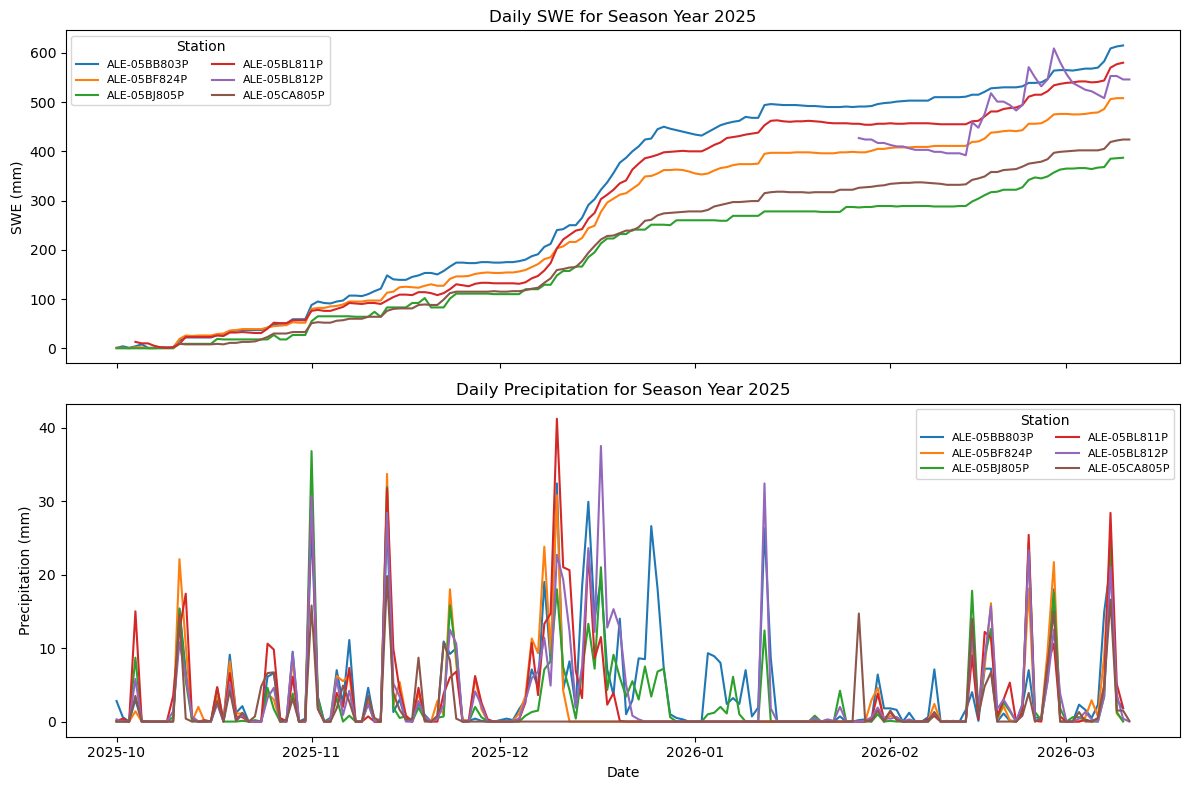

In [6]:
# plot daily SWE and precipitation for season 2025
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for station_id, group in season_2025_df.groupby('station_id'):
    axes[0].plot(group['time'], group['SWE'], label=station_id)
    axes[1].plot(group['time'], group['Precipitation'], label=station_id)

axes[0].set_title('Daily SWE for Season Year 2025')
axes[0].set_ylabel('SWE (mm)')
axes[0].legend(title='Station', ncol=2, fontsize=8)

axes[1].set_title('Daily Precipitation for Season Year 2025')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend(title='Station', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# remove 05BL812
season_2025_df = season_2025_df[season_2025_df['station_id'] != 'ALE-05BL812P']
display(season_2025_df)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year
205,ALE-05BB803P,2025-10-01,1.0,2.8,10,2025,2025
206,ALE-05BB803P,2025-10-02,4.0,0.6,10,2025,2025
207,ALE-05BB803P,2025-10-03,1.0,0.0,10,2025,2025
208,ALE-05BB803P,2025-10-04,4.0,3.0,10,2025,2025
209,ALE-05BB803P,2025-10-05,8.0,0.0,10,2025,2025
...,...,...,...,...,...,...,...
2190,ALE-05CA805P,2026-03-07,405.0,4.8,3,2026,2025
2191,ALE-05CA805P,2026-03-08,419.0,16.6,3,2026,2025
2192,ALE-05CA805P,2026-03-09,422.0,1.5,3,2026,2025
2193,ALE-05CA805P,2026-03-10,424.0,1.5,3,2026,2025


In [8]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(season_2025_df['station_id'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05CA805P']


# Data Preparation

Station Data

In [ ]:
def extract_station_id(filepath):
    """
    Extract station id from filenames like:
    05BB803_SW_C.Corrected-Seasonal.csv
    """
    fname = Path(filepath).name
    m = re.search(r'([0-9A-Za-z]+)_', fname)
    return m.group(1) if m else fname


def find_data_start(filepath):
    """
    Find the row number right after the '#Timestamp;Value' line.
    """
    with open(filepath, 'r', encoding='utf-8-sig', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('#Timestamp;Value'):
                return i + 1
    raise ValueError(f"Could not find '#Timestamp;Value' header in {filepath}")


def read_alberta_timeseries(filepath, value_name='SWE'):
    """
    Read one Alberta seasonal CSV file.

    Returns columns:
    station_id, time, SWE
    """
    station_id = extract_station_id(filepath)
    skiprows = find_data_start(filepath)

    df = pd.read_csv(
        filepath,
        sep=';',
        skiprows=skiprows,
        names=['Timestamp', 'Value'],
        encoding='utf-8-sig'
    )

    df['time'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df[value_name] = pd.to_numeric(df['Value'], errors='coerce')

    df = df.dropna(subset=['time']).copy()
    df['station_id'] = station_id

    return df[['station_id', 'time', value_name]]


def add_season_year_nov_may(df, time_col='time'):
    """
    Keep only Nov-May data and assign season_year.

    Example:
    Nov-Dec 1984 -> season_year 1984
    Jan-May 1985 -> season_year 1984
    """
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    out = out.dropna(subset=[time_col]).copy()
    out['month'] = out[time_col].dt.month
    out['year'] = out[time_col].dt.year

    # Keep only Nov-May
    out = out[out['month'].isin([11, 12, 1, 2, 3, 4, 5])].copy()

    out['season_year'] = out['year']
    out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'season_year'] = (
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
    )

    out = out.drop(columns=['month', 'year'])

    return out


def read_all_alberta_csvs(folderpath, value_name='SWE'):
    """
    Read all CSV files in a folder and combine them.

    Returns columns:
    station_id, time, SWE
    """
    folder = Path(folderpath)
    csv_files = sorted(folder.glob('*.csv'))

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    all_dfs = []
    for file in csv_files:
        try:
            df = read_alberta_timeseries(file, value_name=value_name)
            all_dfs.append(df)
            print(f"Read: {file.name} -> {len(df)} rows")
        except Exception as e:
            print(f"Skipped {file.name}: {e}")

    if not all_dfs:
        raise ValueError("No valid CSV files were read.")

    combined = pd.concat(all_dfs, ignore_index=True)
    combined = combined.sort_values(['station_id', 'time']).reset_index(drop=True)

    return combined


def build_swe_table(folderpath):
    """
    Full pipeline:
    1. Read all CSVs in folder
    2. Add season_year
    3. Return final table with columns:
       station_id, time, SWE, season_year
    """
    df = read_all_alberta_csvs(folderpath, value_name='SWE')
    df = add_season_year_oct_may(df, time_col='time')

    df = df[['station_id', 'time', 'SWE', 'season_year']].copy()
    df = df.sort_values(['station_id', 'time']).reset_index(drop=True)

    return df

def daily_aggregate(df, value_col='SWE', how='last'):
    """
    Aggregate to daily data by station.
    For SWE, 'last' is usually the best choice.
    """
    if how == 'sum':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .sum()
              .reset_index()
        )
    elif how == 'mean':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .mean()
              .reset_index()
        )
    elif how == 'last':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .last()
              .reset_index()
        )
    else:
        raise ValueError("how must be 'sum', 'mean', or 'last'")


In [34]:
# Open CSVs, keep last SWE value per day, and create daily tables

# Bow basin
bow_raw = build_swe_table(config['input_data_bow'])
bow_swe_table = (
    bow_raw.sort_values(['station_id', 'time'])
           .set_index('time')
           .groupby('station_id')['SWE']
           .resample('D')
           .last()
           .reset_index()
)
bow_swe_table = add_season_year_oct_may(bow_swe_table, time_col='time')

# Oldman basin
oldman_raw = build_swe_table(config['input_data_oldman'])
oldman_swe_table = (
    oldman_raw.sort_values(['station_id', 'time'])
              .set_index('time')
              .groupby('station_id')['SWE']
              .resample('D')
              .last()
              .reset_index()
)
oldman_swe_table = add_season_year_oct_may(oldman_swe_table, time_col='time')

# Optional combined daily table
daily_table = pd.concat(
    [
        bow_swe_table.assign(basin='bow'),
        oldman_swe_table.assign(basin='oldman')
    ],
    ignore_index=True
)

display(bow_swe_table.head())
display(oldman_swe_table.head())
display(daily_table.head())

Read: 05BB803_SW_C.Corrected-Seasonal.csv -> 355129 rows
Read: 05BF824_SW_C.Corrected-Seasonal.csv -> 339487 rows
Read: 05BJ805_SW_C.Corrected-Seasonal.csv -> 323828 rows
Read: 05BL811_SW_C.Corrected-Seasonal.csv -> 282719 rows
Read: 05BL812_SW_C.Corrected-Seasonal.csv -> 333428 rows
Read: 05CA805_SW_C.Corrected-Seasonal.csv -> 251112 rows
Read: 05AA809_SW_C.Corrected-Seasonal.csv -> 290591 rows
Read: 05AA817_SW_C.Corrected-Seasonal.csv -> 255260 rows
Read: 05AD803_SW_C.Corrected-Seasonal.csv -> 62356 rows


,station_id,time,SWE,season_year
0,05BB803,1984-03-12,473.0,1983
1,05BB803,1984-03-13,485.0,1983
2,05BB803,1984-03-14,492.0,1983
3,05BB803,1984-03-15,492.0,1983
4,05BB803,1984-03-16,492.0,1983


,station_id,time,SWE,season_year
0,05AA809,1984-04-01,428.0,1983
1,05AA809,1984-04-02,429.0,1983
2,05AA809,1984-04-03,429.0,1983
3,05AA809,1984-04-04,430.0,1983
4,05AA809,1984-04-05,443.0,1983


,station_id,time,SWE,season_year,basin
0,05BB803,1984-03-12,473.0,1983,bow
1,05BB803,1984-03-13,485.0,1983,bow
2,05BB803,1984-03-14,492.0,1983,bow
3,05BB803,1984-03-15,492.0,1983,bow
4,05BB803,1984-03-16,492.0,1983,bow


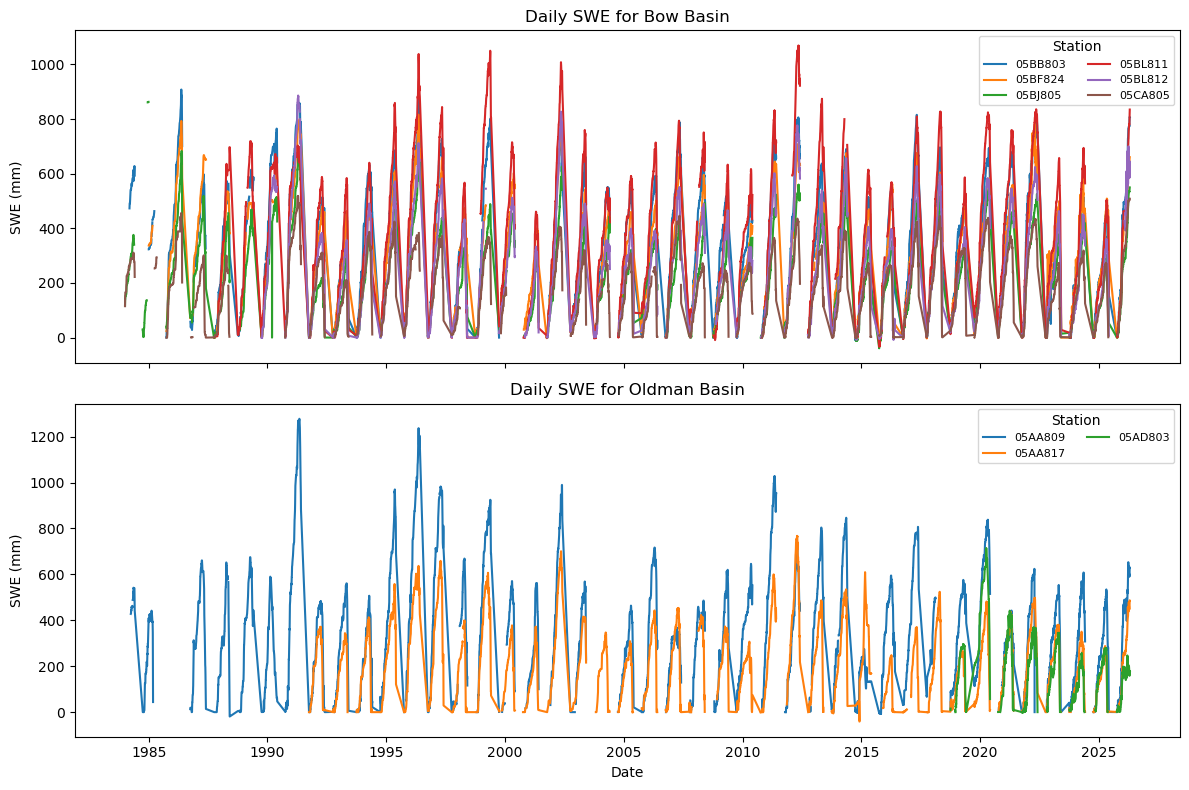

In [32]:
# plot daily SWE for all stations in Bow basin and Oldman basin
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for station_id, group in bow_swe_table.groupby('station_id'):
    axes[0].plot(group['time'], group['SWE'], label=station_id)
for station_id, group in oldman_swe_table.groupby('station_id'):
    axes[1].plot(group['time'], group['SWE'], label=station_id)
axes[0].set_title('Daily SWE for Bow Basin')
axes[0].set_ylabel('SWE (mm)')
axes[0].legend(title='Station', ncol=2, fontsize=8)
axes[1].set_title('Daily SWE for Oldman Basin')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('SWE (mm)')
axes[1].legend(title='Station', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

get gapfilled data for SWEI timeseries

In [5]:
# open gapfilled and original CANSWE data 
gapfilled_ds = xr.open_dataset(config['gap_filled_canswe_data'])
original_ds = xr.open_dataset(config['canswe_original_data'])

# filter Elevation_Category = 2000_2500m from original_ds and merge with gapfilled_ds
original_df = original_ds.to_dataframe().reset_index()
original_df = original_df[original_df['Elevation_Category'] == '2000_2500m']
gapfilled_df = gapfilled_ds.to_dataframe().reset_index()
merged_df = pd.merge(
    original_df,
    gapfilled_df,
    on=['time', 'station_id'],
    how='outer',
    suffixes=('_original', '_gapfilled')
)

# drop lat_gapfilled, lon_gapfilled,station_name_gapfilled
merged_df = merged_df.drop(columns=['lat_gapfilled', 'lon_gapfilled', 'station_name_original'])
display(merged_df.head())

,time,station_id,snw,lat_original,lon_original,Elevation_Category,station_name_gapfilled,SWE
0,1980-01-01,ALE-05BA806,NaN,51.416618,-116.238274,2000_2500m,MIRROR LAKE,NaN
1,1980-01-01,ALE-05BA810,NaN,51.474091,-116.102745,2000_2500m,PTARMIGAN HUT,NaN
2,1980-01-01,ALE-05BA811,NaN,51.700001,-116.466667,2000_2500m,BOW SUMMIT (OLD),NaN
3,1980-01-01,ALE-05BA812,NaN,51.325008,-116.206169,2000_2500m,LARCH VALLEY,NaN
4,1980-01-01,ALE-05BA813,NaN,51.710014,-116.478073,2000_2500m,BOW SUMMIT (NEW),NaN


In [6]:
# check if nan in station_name_original
print("Unique station_name_gapfilled values:")
print(merged_df['station_name_gapfilled'].unique())

Unique station_name_gapfilled values:
['MIRROR LAKE' 'PTARMIGAN HUT' 'BOW SUMMIT (OLD)' 'LARCH VALLEY'
 'BOW SUMMIT (NEW)' 'KATHERINE LAKE' 'SUNSHINE VILLAGE'
 'SUNSHINE VILLAGE PILLOW' 'TENT RIDGE' 'CUTHEAD LAKE' 'THREE ISLE LAKE'
 'THREE ISLE LAKE PILLOW' 'LITTLE ELBOW' 'LITTLE ELBOW SUMMIT PILLOW'
 'HIGHWOOD S. OPEN' 'HIGHWOOD S. BUSH' 'LOST CREEK'
 'LOST CREEK SOUTH PILLOW' 'MOUNT ODLUM III' 'MOUNT ODLUM PILLOW'
 'SKOKI MOUNTAIN' 'SKOKI LODGE PILLOW' 'STORM CREEK' 'MARMOT CREEK 14'
 'MARMOT CREEK 18' 'MARMOT CREEK 19' 'MARMOT CREEK 20' 'MARMOT CREEK 21'
 'MARMOT CREEK 22' 'Bonsai' 'CanadianRidge_ridge'
 'CanadianRidge_New_NF_slope' 'FortressRidgeSouth' 'FortressRidge_ridge'
 'Powerline_clearing' 'Powerline_forest' 'FiseraRidge_Northface'
 'Fisera_Ridgetop_forest' 'Fisera_Ridgetop' 'Fisera_Lower_Southface'
 'Fisera_Ridgetop_Southface_forest' 'Fisera_Upper_Southface' 'BOW RIVER'
 'PIPESTONE UPPER' 'CHATEAU LAWN' 'MUD LAKE' 'WILKINSON S.BUSH'
 'WILKINSON S.OPEN' 'MIST  CREEK' 'MOUNT O

In [7]:
# assign Seasonal_Year to merged_df

def select_seasonal_data(ts, start_month, end_month, min_year, max_year):
    month = ts.month
    year = ts.year
    if month >= start_month:
        seasonal_year = year
    elif month <= end_month:
        seasonal_year = year - 1
    else:
        return np.nan
    return seasonal_year if (min_year <= seasonal_year <= max_year) else np.nan

# For CanSWE data
merged_df['Seasonal_Year'] = merged_df['time'].apply(
    lambda ts: select_seasonal_data(ts, start_month=10, end_month=9, min_year=1980, max_year=2023)
)

# drop rows with NaN Seasonal_Year
merged_df = merged_df.dropna(subset=['Seasonal_Year']).copy()

# drop snw,lat_original, lon_original, station_name_original, Elevation_Category
merged_df = merged_df.drop(columns=['snw', 'lat_original', 'lon_original',  'Elevation_Category'])

display(merged_df.head())

,time,station_id,station_name_gapfilled,SWE,Seasonal_Year
11508,1980-10-01,ALE-05BA806,MIRROR LAKE,NaN,1980.0
11509,1980-10-01,ALE-05BA810,PTARMIGAN HUT,NaN,1980.0
11510,1980-10-01,ALE-05BA811,BOW SUMMIT (OLD),NaN,1980.0
11511,1980-10-01,ALE-05BA812,LARCH VALLEY,NaN,1980.0
11512,1980-10-01,ALE-05BA813,BOW SUMMIT (NEW),NaN,1980.0


In [8]:
#Filter to station_ids 'ALE-05BB803P','ALE-05BF824P','ALE-05BJ805P','ALE-05BL811P','ALE-05CA805P'
filtered_station = merged_df[
    merged_df['station_id'].isin([
        'ALE-05BB803P',
        'ALE-05BF824P',
        'ALE-05BJ805P',
        'ALE-05BL811P',
        'ALE-05CA805P',
        'ALE-05BL812P'
    ])
].copy()
display(filtered_station.head())

,time,station_id,station_name_gapfilled,SWE,Seasonal_Year
11515,1980-10-01,ALE-05BB803P,SUNSHINE VILLAGE PILLOW,NaN,1980.0
11519,1980-10-01,ALE-05BF824P,THREE ISLE LAKE PILLOW,NaN,1980.0
11521,1980-10-01,ALE-05BJ805P,LITTLE ELBOW SUMMIT PILLOW,0.0,1980.0
11525,1980-10-01,ALE-05BL811P,LOST CREEK SOUTH PILLOW,NaN,1980.0
11527,1980-10-01,ALE-05BL812P,MOUNT ODLUM PILLOW,NaN,1980.0


In [9]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(filtered_station['station_id'].unique())
print(filtered_station['station_name_gapfilled'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05BL812P' 'ALE-05CA805P']
['SUNSHINE VILLAGE PILLOW' 'THREE ISLE LAKE PILLOW'
 'LITTLE ELBOW SUMMIT PILLOW' 'LOST CREEK SOUTH PILLOW'
 'MOUNT ODLUM PILLOW' 'SKOKI LODGE PILLOW']


In [10]:
# add station_name_gapfilled to season_2025_df by mapping station_id
station_name_map = filtered_station.set_index('station_id')['station_name_gapfilled'].to_dict()
season_2025_df['station_name_gapfilled'] = season_2025_df['station_id'].map(station_name_map)
display(season_2025_df)


# add season_2025_df data to the bottom of filtered_station
final_df = pd.concat([filtered_station, season_2025_df], ignore_index=True)
#drop month, year, Precipitation columns from final_df
final_df = final_df.drop(columns=['month', 'year', 'Precipitation'])

display(final_df)

NameError: name 'season_2025_df' is not defined

In [46]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(final_df['station_id'].unique())
print(final_df['station_name_gapfilled'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05CA805P']
['SUNSHINE VILLAGE PILLOW' 'THREE ISLE LAKE PILLOW'
 'LITTLE ELBOW SUMMIT PILLOW' 'LOST CREEK SOUTH PILLOW'
 'SKOKI LODGE PILLOW']


In [47]:
season_2025_weekly = final_df[final_df['Seasonal_Year'] == 2025].copy()
display(season_2025_weekly.head())

,time,station_id,station_name_gapfilled,SWE,Seasonal_Year
80050,2025-10-01,ALE-05BB803P,SUNSHINE VILLAGE PILLOW,1.0,2025.0
80051,2025-10-02,ALE-05BB803P,SUNSHINE VILLAGE PILLOW,4.0,2025.0
80052,2025-10-03,ALE-05BB803P,SUNSHINE VILLAGE PILLOW,1.0,2025.0
80053,2025-10-04,ALE-05BB803P,SUNSHINE VILLAGE PILLOW,4.0,2025.0
80054,2025-10-05,ALE-05BB803P,SUNSHINE VILLAGE PILLOW,8.0,2025.0


# Classification

In [19]:
# calculate running monthly SWE and cumulative precipitation 
def calculate_running_oct_may_swe_precip(
    df,
    time_col='time',
    station_col='station_id',
    swe_col='SWE',
    precip_col='Precipitation',
    season_col='Seasonal_Year'
):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    # keep only Oct-May
    out = out[out[time_col].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])].copy()

    # if Seasonal_Year is not already there, create it
    if season_col not in out.columns:
        out['month'] = out[time_col].dt.month
        out['year'] = out[time_col].dt.year
        out[season_col] = out['year']
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), season_col] = (
            out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
        )

    out['month'] = out[time_col].dt.month

    # season month order: Oct=1, Nov=2, ..., May=8
    season_month_map = {10: 1, 11: 2, 12: 3, 1: 4, 2: 5, 3: 6, 4: 7, 5: 8}
    out['season_month_order'] = out['month'].map(season_month_map)

    results = []

    for (station_id, seasonal_year), group in out.groupby([station_col, season_col], dropna=False):
        group = group.sort_values(time_col).copy()

        for current_order in range(1, 9):
            subset = group[group['season_month_order'] <= current_order].copy()

            if subset.empty:
                continue

            current_month = [k for k, v in season_month_map.items() if v == current_order][0]

            results.append({
                station_col: station_id,
                season_col: seasonal_year,
                'month': current_month,
                'season_month_order': current_order,
                'mean_SWE': subset[swe_col].mean(skipna=True),
                'cumulative_P': subset[precip_col].sum(skipna=True)
            })

    result_df = pd.DataFrame(results).sort_values(
        [station_col, season_col, 'season_month_order']
    ).reset_index(drop=True)

    return result_df

In [18]:
#calculate running monthly SWE and cumulative precipitation for season 2025
classification_df = calculate_running_oct_may_swe_precip(season_2025_df)

# caculate mean_SWE/Cum_P
classification_df['SWE_P_ratio'] = classification_df['mean_SWE'] / classification_df['cumulative_P']



display(classification_df.head(12))

,station_id,Seasonal_Year,month,season_month_order,mean_SWE,cumulative_P,SWE_P_ratio
0,ALE-05BB803P,2025,10,1,25.548387,67.2,0.380184
1,ALE-05BB803P,2025,11,2,79.885246,189.6,0.421336
2,ALE-05BB803P,2025,12,3,157.510870,461.9,0.341006
3,ALE-05BB803P,2025,1,4,238.487805,550.3,0.433378
4,ALE-05BB803P,2025,2,5,290.947020,619.5,0.469648
5,ALE-05BB803P,2025,3,6,309.031056,667.3,0.463107
6,ALE-05BB803P,2025,4,7,309.031056,667.3,0.463107
7,ALE-05BB803P,2025,5,8,309.031056,667.3,0.463107
8,ALE-05BF824P,2025,10,1,25.225806,65.1,0.387493
9,ALE-05BF824P,2025,11,2,70.295082,204.2,0.344246


In [19]:
# drop months 4 and 5 (April and May) for the report
classification_df = classification_df[~classification_df['month'].isin([4, 5])].copy()
display(classification_df)

,station_id,Seasonal_Year,month,season_month_order,mean_SWE,cumulative_P,SWE_P_ratio
0,ALE-05BB803P,2025,10,1,25.548387,67.2,0.380184
1,ALE-05BB803P,2025,11,2,79.885246,189.6,0.421336
2,ALE-05BB803P,2025,12,3,157.510870,461.9,0.341006
3,ALE-05BB803P,2025,1,4,238.487805,550.3,0.433378
4,ALE-05BB803P,2025,2,5,290.947020,619.5,0.469648
5,ALE-05BB803P,2025,3,6,309.031056,667.3,0.463107
8,ALE-05BF824P,2025,10,1,25.225806,65.1,0.387493
9,ALE-05BF824P,2025,11,2,70.295082,204.2,0.344246
10,ALE-05BF824P,2025,12,3,134.217391,297.6,0.450999
11,ALE-05BF824P,2025,1,4,197.878049,305.1,0.648568


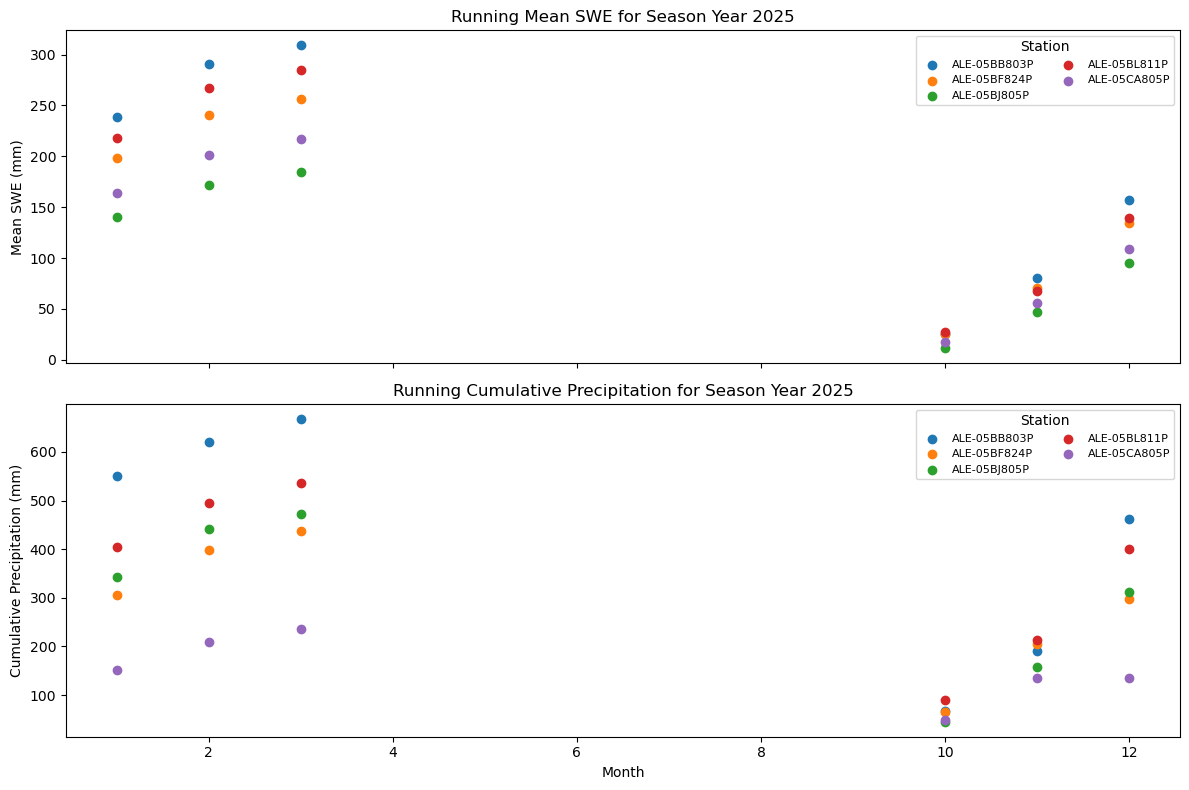

In [20]:
# plot monthly SWE and cumulative precipitation for season 2025
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for station_id, group in classification_df.groupby('station_id'):
    axes[0].scatter(group['month'], group['mean_SWE'], marker='o', label=station_id)
    axes[1].scatter(group['month'], group['cumulative_P'], marker='o', label=station_id)
axes[0].set_title('Running Mean SWE for Season Year 2025')
axes[0].set_ylabel('Mean SWE (mm)')
axes[0].legend(title='Station', ncol=2, fontsize=8)
axes[1].set_title('Running Cumulative Precipitation for Season Year 2025')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cumulative Precipitation (mm)')
axes[1].legend(title='Station', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
def calculate_monthly_swe_precip_resample(
    df,
    time_col='time',
    station_col='station_id',
    swe_col='SWE',
    precip_col='Precipitation'
):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    monthly = (
        out.set_index(time_col)
           .groupby(station_col)
           .resample('M')
           .agg({
               swe_col: 'mean',
               precip_col: 'sum'
           })
           .rename(columns={
               swe_col: 'mean_SWE',
               precip_col: 'cumulative_P'
           })
           .reset_index()
    )

    monthly['year'] = monthly[time_col].dt.year
    monthly['month'] = monthly[time_col].dt.month

    if 'Seasonal_Year' in out.columns:
        monthly['Seasonal_Year'] = monthly[time_col].dt.year
        monthly.loc[monthly['month'].isin([1, 2, 3, 4, 5]), 'Seasonal_Year'] = (
            monthly.loc[monthly['month'].isin([1, 2, 3, 4, 5]), time_col].dt.year - 1
        )
        monthly.loc[monthly['month'].isin([10, 11, 12]), 'Seasonal_Year'] = (
            monthly.loc[monthly['month'].isin([10, 11, 12]), time_col].dt.year
        )

    return monthly

monthly_df = (
    season_2025_df
    .groupby(['station_id', 'Seasonal_Year', season_2025_df['time'].dt.month], dropna=False)
    .agg(
        mean_SWE=('SWE_change', 'mean'),
        cumulative_P=('Precipitation', 'sum')
    )
    .reset_index()
    .rename(columns={'time': 'month'})
)

display(monthly_df.head())

KeyError: "Column(s) ['SWE_change'] do not exist"

# Calculate SWEI

In [ ]:
# monthly SWEI calculation functions 

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id","station_name_gapfilled"]]
        .drop_duplicates(subset=["station_id", "station_name_gapfilled"])
        .set_index("station_id")
    )


def daily_to_monthly_swe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily SWE → monthly integrated SWE.
    Seasonal_Year is recomputed from time.
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    monthly = (
        out
        .groupby(
            ["station_id", pd.Grouper(key="time", freq="MS")],
            as_index=False
        )
        .agg(
            SWE_monthly=("SWE", "sum")
        )
    )

    # Recompute Seasonal_Year (e.g., Oct–Sep water year)
    monthly["Seasonal_Year"] = np.where(
        monthly["time"].dt.month >= 10,
        monthly["time"].dt.year,
        monthly["time"].dt.year - 1
    )

    return monthly



def rolling_integrated_swe_by_season(
    monthly_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:
    """
    Compute rolling k‑month integrated SWE within each Seasonal_Year.

    • Rolling windows do NOT cross Seasonal_Year boundaries.
    • First (k‑1) months of each season are dropped.
    • Works for any window (3, 6, 8, …).
    """

    out = monthly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_months}mo"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_monthly"]
        .rolling(window=window_months, min_periods=window_months)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_months}mo"])



def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    # ranks with average ties
    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute SWEI for ONE Grid_id using calendar-month standardization.
    """
    out = df.copy()
    out["month"] = out["time"].dt.month

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for m in range(1, 13):
        idx = out["month"] == m
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue  # Near-normal (NN)

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out



def compute_swei(
    df: pd.DataFrame,
    window_months: int = 3
) -> pd.DataFrame:
    """
    End‑to‑end SWEI calculation with metadata preservation.
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily → monthly SWE
    monthly = daily_to_monthly_swe(df)

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season(monthly, window_months)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid(
                g,
                swe_col=f"SWE_{window_months}mo"
            )
        )
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei


In [49]:
# 1-month SWEI
swei_1mo = compute_swei(final_df, window_months=1)
#swei_1mo_output_dir = config['output_plots'] / 'swei_1mo'
#swei_1mo_output_dir.mkdir(parents=True, exist_ok=True)
#swei_1mo.to_csv(swei_1mo_output_dir / 'swei_1mo.csv', index=False)

display(swei_1mo)

,station_id,time,SWE_monthly,Seasonal_Year,SWE_1mo,month,Gringorten_p,SWEI,station_name_gapfilled
0,ALE-05BB803P,1980-10-01,0.0,1980,0.0,10,0.056738,-1.582764,SUNSHINE VILLAGE PILLOW
1,ALE-05BB803P,1980-11-01,0.0,1980,0.0,11,0.056738,-1.582764,SUNSHINE VILLAGE PILLOW
2,ALE-05BB803P,1980-12-01,0.0,1980,0.0,12,0.056738,-1.582764,SUNSHINE VILLAGE PILLOW
3,ALE-05BB803P,1981-01-01,0.0,1980,0.0,1,0.045656,-1.688517,SUNSHINE VILLAGE PILLOW
4,ALE-05BB803P,1981-02-01,0.0,1980,0.0,2,0.045656,-1.688517,SUNSHINE VILLAGE PILLOW
...,...,...,...,...,...,...,...,...,...
2655,ALE-05CA805P,2025-11-01,2462.0,2025,2462.0,11,0.699468,0.522871,SKOKI LODGE PILLOW
2656,ALE-05CA805P,2025-12-01,6133.0,2025,6133.0,12,0.921099,1.412505,SKOKI LODGE PILLOW
2657,ALE-05CA805P,2026-01-01,9611.0,2025,9611.0,1,0.965426,1.817445,SKOKI LODGE PILLOW
2658,ALE-05CA805P,2026-02-01,9870.0,2025,9870.0,2,0.965426,1.817445,SKOKI LODGE PILLOW


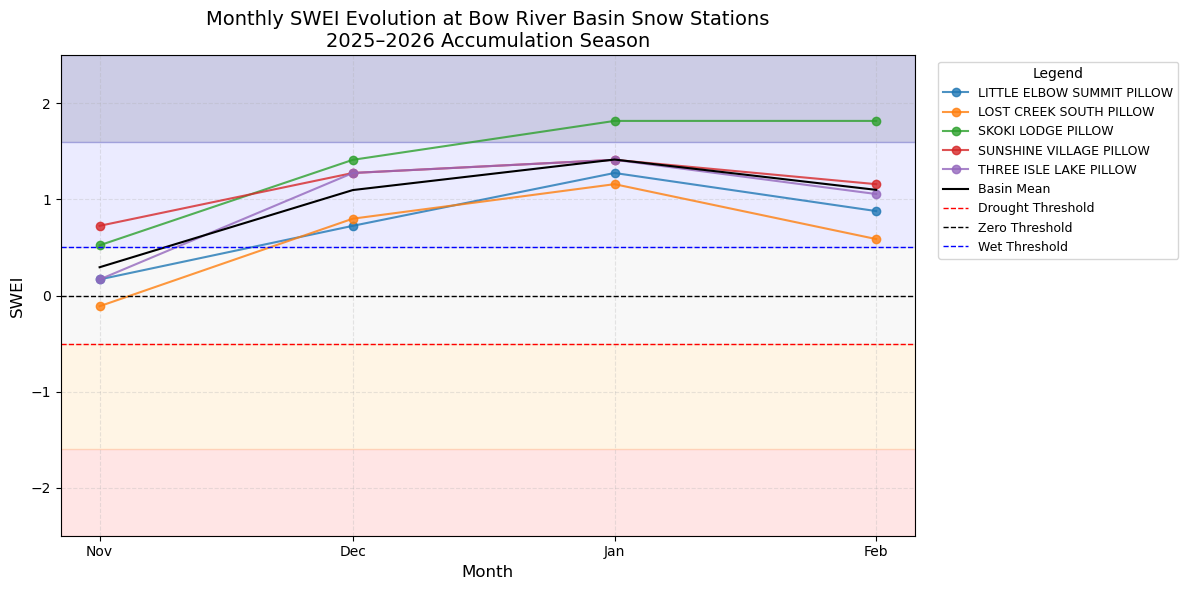

In [76]:
# plot for monthly SWEI season 2025
season_2025_Monthly = swei_1mo[swei_1mo['Seasonal_Year'] == 2025].copy()

# remove March  and October for the report
season_2025_Monthly = season_2025_Monthly[~season_2025_Monthly['time'].dt.month.isin([3, 10])].copy()


fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_name_gapfilled, group in season_2025_Monthly.groupby('station_name_gapfilled'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_name_gapfilled)
    

# --- optional basin mean ---
basin_mean = season_2025_Monthly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='-',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1, label='Drought Threshold')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Threshold')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='Wet Threshold')

# --- labels ---
ax.set_title('Monthly SWEI Evolution at Bow River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Legend',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
save_path = config['output_plots'] / 'season_2025_monthly_swei.png'
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()

In [69]:
# weekly SWEI calculation functions

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id","station_name_gapfilled"]]
        .drop_duplicates(subset=["station_id", "station_name_gapfilled"])
        .set_index("station_id")
    )


def daily_to_weekly_swe(
    df: pd.DataFrame,
    week_freq: str = "W-SUN",
    weekly_agg: str = "last"
) -> pd.DataFrame:
    """
    Daily SWE -> weekly SWE.

    Parameters
    ----------
    week_freq : str
        Weekly resampling frequency, e.g. 'W-SUN', 'W-MON'
    weekly_agg : str
        Aggregation within week: 'last', 'mean', or 'max'

    Returns
    -------
    DataFrame with columns:
        station_id, time, SWE_weekly, Seasonal_Year, season_week
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    if weekly_agg == "last":
        weekly = (
            out.set_index("time")
            .groupby("station_id")["SWE"]
            .resample(week_freq)
            .last()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "mean":
        weekly = (
            out.set_index("time")
            .groupby("Grid_id")["SWE"]
            .resample(week_freq)
            .mean()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "max":
        weekly = (
            out.set_index("time")
            .groupby("Grid_id")["SWE"]
            .resample(week_freq)
            .max()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    else:
        raise ValueError("weekly_agg must be one of: 'last', 'mean', 'max'")

    # Recompute Seasonal_Year using Oct-May style start year
    # Oct 2025 - May 2026 => Seasonal_Year = 2025
    weekly["Seasonal_Year"] = np.where(
        weekly["time"].dt.month >= 10,
        weekly["time"].dt.year,
        weekly["time"].dt.year - 1
    )

    # Define season start = Oct 1 of Seasonal_Year
    season_start = pd.to_datetime(weekly["Seasonal_Year"].astype(str) + "-10-01")

    # season_week = week number within season
    weekly["season_week"] = ((weekly["time"] - season_start).dt.days // 7) + 1

    # Optional: keep only Oct-May season weeks
    weekly = weekly[
        weekly["time"].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])
    ].copy()

    return weekly


def rolling_integrated_swe_by_season_weekly(
    weekly_df: pd.DataFrame,
    window_weeks: int
) -> pd.DataFrame:
    """
    Compute rolling k-week integrated SWE within each Seasonal_Year.

    - Rolling windows do NOT cross Seasonal_Year boundaries.
    - First (k-1) weeks of each season are dropped.
    """
    out = weekly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_weeks}wk"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_weekly"]
        .rolling(window=window_weeks, min_periods=window_weeks)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_weeks}wk"])


def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid_weekly(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute weekly SWEI for ONE station_id using season-week standardization.

    Each week is standardized against the historical distribution of
    the same season_week for that station.
    """
    out = df.copy()

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for wk in sorted(out["season_week"].dropna().unique()):
        idx = out["season_week"] == wk
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out


def compute_weekly_swei(
    df: pd.DataFrame,
    window_weeks: int = 4,
    week_freq: str = "W-SUN",
    weekly_agg: str = "last"
) -> pd.DataFrame:
    """
    End-to-end weekly SWEI calculation with metadata preservation.

    Steps:
    1. Daily -> weekly SWE
    2. Rolling k-week integrated SWE within season
    3. Compute SWEI per Grid_id using season-week climatology
    4. Reattach static metadata
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily -> weekly SWE
    weekly = daily_to_weekly_swe(
        df,
        week_freq=week_freq,
        weekly_agg=weekly_agg
    )

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season_weekly(weekly, window_weeks)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid_weekly(
                g,
                swe_col=f"SWE_{window_weeks}wk"
            )
        )
        .reset_index(drop=True)
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei

In [70]:
#Weekly SWEI historic SWEI calculation
weekly_swei = compute_weekly_swei(
    df=final_df,
    window_weeks=1,      # 1-week SWEI
    week_freq="W-SUN",   # weekly ending Sunday
    weekly_agg="last"    # recommended for SWE
)

display(weekly_swei.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name_gapfilled
0,ALE-05BB803P,1981-03-22,493.24,1980,25,493.24,0.352675,-0.378110,SUNSHINE VILLAGE PILLOW
1,ALE-05BB803P,1981-03-29,499.15,1980,26,499.15,0.262013,-0.637153,SUNSHINE VILLAGE PILLOW
2,ALE-05BB803P,1981-04-05,537.79,1980,27,537.79,0.398005,-0.258513,SUNSHINE VILLAGE PILLOW
3,ALE-05BB803P,1981-04-12,554.87,1980,28,554.87,0.420671,-0.200177,SUNSHINE VILLAGE PILLOW
4,ALE-05BB803P,1981-04-19,558.55,1980,29,558.55,0.330009,-0.439888,SUNSHINE VILLAGE PILLOW


In [71]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(weekly_swei['station_id'].unique())
print(weekly_swei['station_name_gapfilled'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05CA805P']
['SUNSHINE VILLAGE PILLOW' 'THREE ISLE LAKE PILLOW'
 'LITTLE ELBOW SUMMIT PILLOW' 'LOST CREEK SOUTH PILLOW'
 'SKOKI LODGE PILLOW']


In [72]:
season_2025_weekly = weekly_swei[weekly_swei['Seasonal_Year'] == 2025].copy()
display(season_2025_weekly.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name_gapfilled
1419,ALE-05BB803P,2025-10-05,8.0,2025,1,8.0,0.539349,0.098795,SUNSHINE VILLAGE PILLOW
1420,ALE-05BB803P,2025-10-12,22.0,2025,2,22.0,0.686939,0.487193,SUNSHINE VILLAGE PILLOW
1421,ALE-05BB803P,2025-10-19,35.0,2025,3,35.0,0.612164,0.284962,SUNSHINE VILLAGE PILLOW
1422,ALE-05BB803P,2025-10-26,49.0,2025,4,49.0,0.637089,0.350688,SUNSHINE VILLAGE PILLOW
1423,ALE-05BB803P,2025-11-02,95.0,2025,5,95.0,0.811565,0.883679,SUNSHINE VILLAGE PILLOW


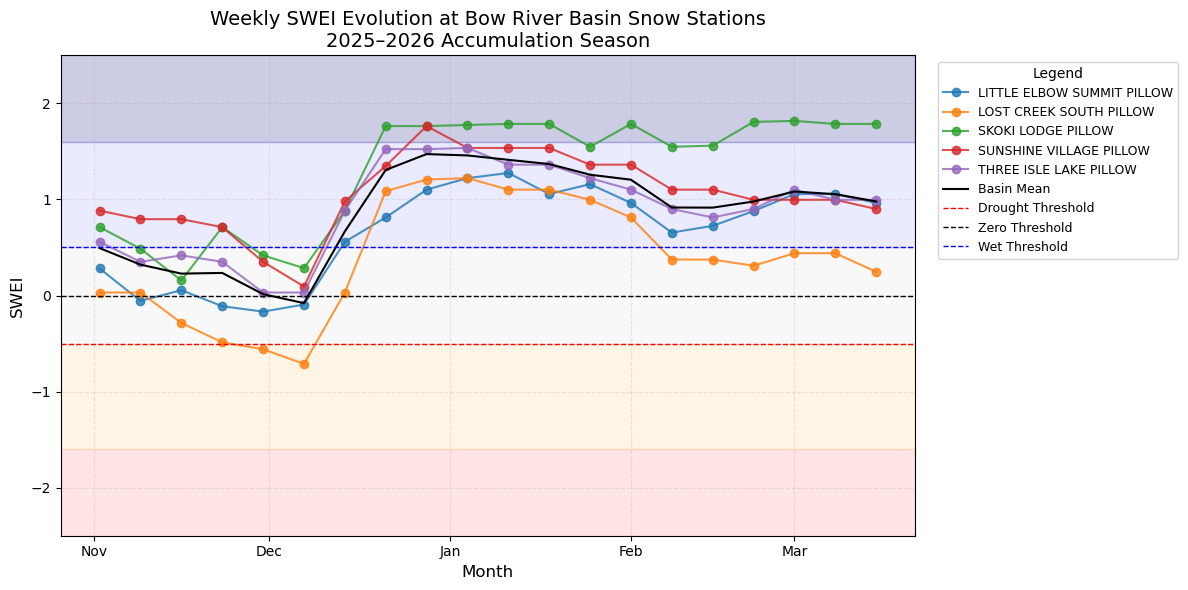

In [77]:
# plot for season 2025
season_2025_weekly = weekly_swei[weekly_swei['Seasonal_Year'] == 2025].copy()

# remove October for the report
season_2025_weekly = season_2025_weekly[season_2025_weekly['time'].dt.month != 10].copy()

fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_name_gapfilled, group in season_2025_weekly.groupby('station_name_gapfilled'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_name_gapfilled)

# --- optional basin mean ---
basin_mean = season_2025_weekly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='-',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1, label='Drought Threshold')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Threshold')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1, label='Wet Threshold')
# --- labels ---
ax.set_title('Weekly SWEI Evolution at Bow River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Legend',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
save_path = config['output_plots'] / 'season_2025_weekly_swei.png'
plt.savefig(save_path, dpi=1000, bbox_inches='tight')
plt.show()

In [30]:
#Average weekly SWEI
avg_weekly_swei = (
    weekly_swei
    .groupby(["Seasonal_Year", "season_week"], dropna=False)
    .agg(Avg_SWEI_1wk=("SWEI", "mean"))
    .reset_index()
)
display(avg_weekly_swei.head(12))

,Seasonal_Year,season_week,Avg_SWEI_1wk
0,1980,1,-0.281445
1,1980,2,-0.587694
2,1980,3,-1.817445
3,1980,4,0.655088
4,1980,5,0.167443
5,1980,6,1.056412
6,1980,7,0.655088
7,1980,8,0.878942
8,1980,9,0.460176
9,1980,15,-0.460176


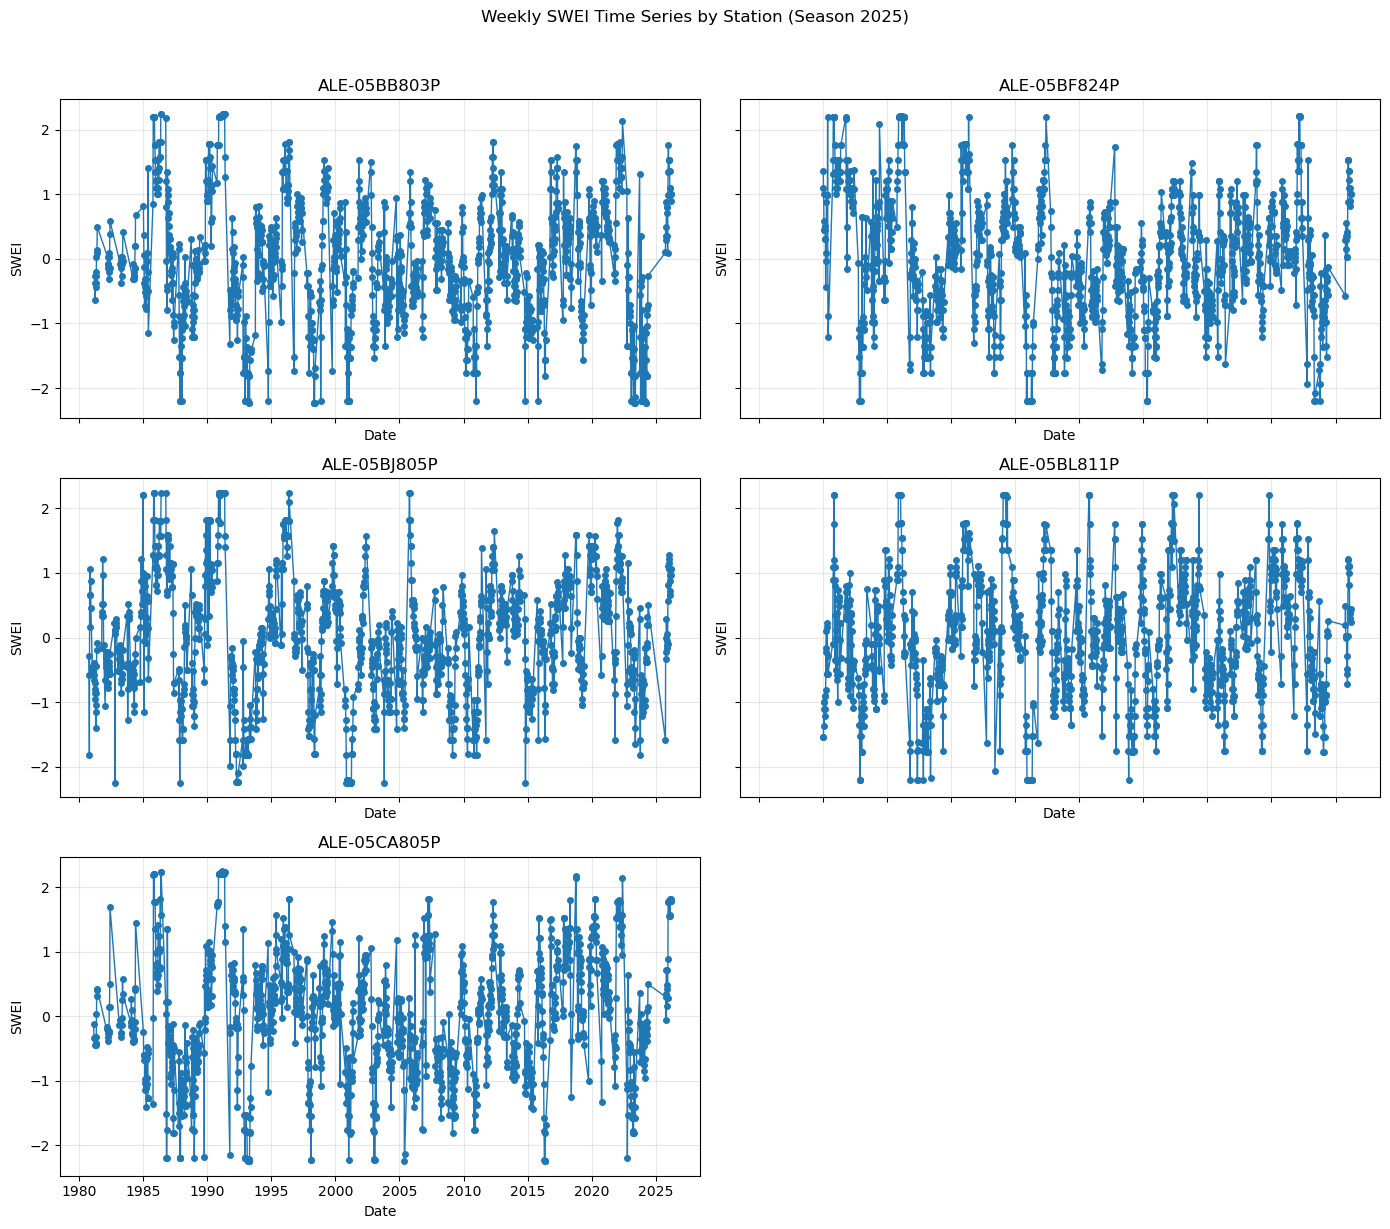

In [32]:
# plot Weekly SWEI time series for each station
# subset to stations with valid SWEI values
valid_stations = weekly_swei.loc[weekly_swei["SWEI"].notna(), "station_id"].unique()
weekly_swei_valid = weekly_swei[weekly_swei["station_id"].isin(valid_stations)].copy()

n_stations = len(valid_stations)
ncols = 2
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, station_id in enumerate(valid_stations):
    ax = axes[i]
    group = weekly_swei_valid[weekly_swei_valid["station_id"] == station_id].sort_values("time")
    ax.plot(group["time"], group["SWEI"], marker="o", markersize=4, linewidth=1)
    ax.set_title(station_id)
    ax.set_ylabel("SWEI")
    ax.grid(alpha=0.3)

for j in range(n_stations, len(axes)):
    axes[j].set_visible(False)

for ax in axes[:n_stations]:
    ax.set_xlabel("Date")
#ax.get_xlim(2025-10,2026-3)
fig.suptitle("Weekly SWEI Time Series by Station (Season 2025)", y=1.02)
plt.tight_layout()
plt.show()